In [392]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [393]:
pgroup = 'p23085'
runlist = [229,230,231]
#runlist = np.arange(180, 186)


data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 229


100%|██████████| 44/44 [00:09<00:00,  4.74it/s]


Processing run 230


100%|██████████| 44/44 [00:09<00:00,  4.83it/s]


Processing run 231


100%|██████████| 35/35 [00:07<00:00,  4.81it/s]


In [371]:
#plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='124', withTT=False, bins=100, figsize=(10, 3))

In [394]:
ui, out  = Rebin_widget(data=data)
ui

In [395]:
out["results1"] = Rebin_with_scanvar_and_filter(signal='diode1', data=data, quantile=0.7, izero='Izero122', TT='126', YAGscan=False, withTT=False)
out["results2"] = Rebin_with_scanvar_and_filter(signal='diode2', data=data, quantile=0.7, izero='Izero122', TT='126', YAGscan=False, withTT=False)
out["params"]   = {'signal1': 'diode1', 'signal2': 'diode2', 'izero': 'Izero122', 'quantile': 0.7, 'TT': '126', 'YAGscan': False, 'withTT': False}

Izero122_pump diode1_pump
59449 shots out of 121828 survived
Izero122_pump diode2_pump
59771 shots out of 121828 survived


In [396]:
data_plot1 = {"results": out['results1'], "params": out['params'], "which": "signal1"}
data_plot2 = {"results": out['results2'], "params": out['params'], "which": "signal2"}
#fig, axes = plotter.shot_noise(data_plot1, meta)

Data saved in /sf/alvra/data/p23085/work/Reduced_data2/_multiruns/run0229_0230_0231/


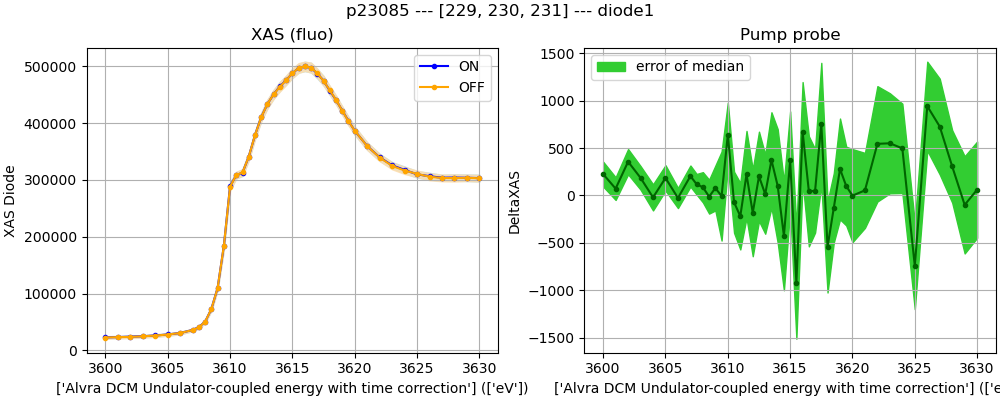

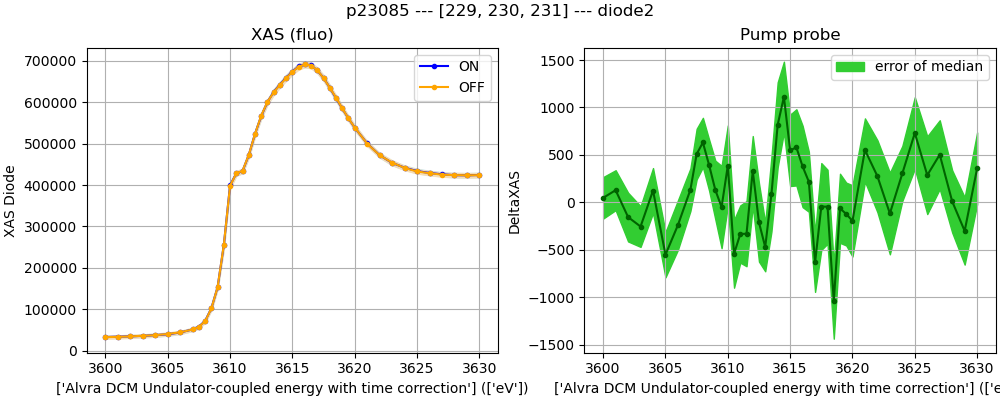

In [397]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2)

fig, axes = plotter.energy_scans(data_plot1, meta, errbars=False)
fig, axes = plotter.energy_scans(data_plot2, meta, errbars=False)

In [384]:
print (data_plot1['results']['GS'][:2])
print (data_plot1['results']['ES'][:2])
print (data_plot1['results']['pp'][:2])

[22915.52759998 23219.17899083]
[22898.35358349 23305.13118854]
[ -14.23814458 -252.01632403]


Data saved in /sf/alvra/data/p23085/work/Reduced_data2/_multiruns/run0229_0230_0231/


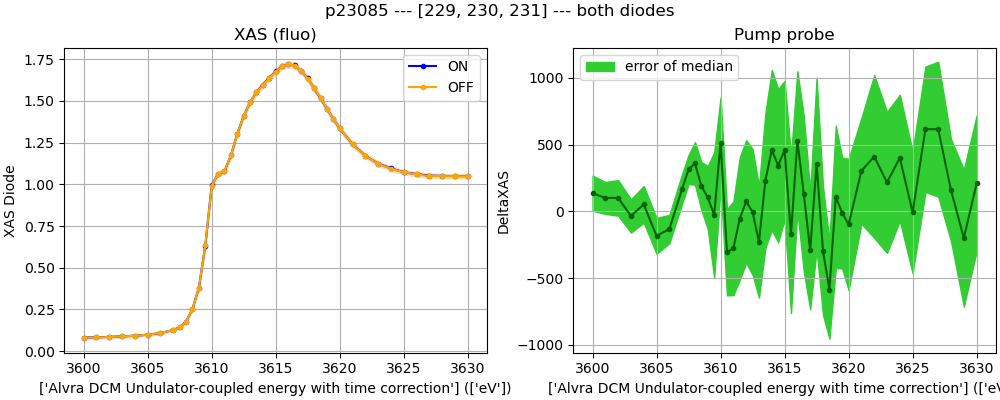

In [398]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=data_plot_both)
fig, axes = plotter.energy_scans(data_plot_both, meta, errbars=False)


In [52]:
data_plot1['results']['scanvar_rebin']

array([3600. , 3601. , 3602. , 3603. , 3604. , 3605. , 3606. , 3607. ,
       3607.5, 3608. , 3608.5, 3609. , 3609.5, 3610. , 3610.5, 3611. ,
       3611.5, 3612. , 3612.5, 3613. , 3613.5, 3614. , 3614.5, 3615. ,
       3615.5, 3616. , 3616.5, 3617. , 3617.5, 3618. , 3618.5, 3619. ,
       3619.5, 3620. , 3621. , 3622. , 3623. , 3624. , 3625. , 3626. ,
       3627. , 3628. , 3629. , 3630. ])

# Overlay data with UI

In [103]:
pgroup = 'p23085'
which_plot = 'both' #both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __both diodes__ from: /sf/alvra/data/p23085/work/Reduced_data2/_multiruns/run0028_0029_0030_0031_0032_0058_0059_0060_0094_0095_0098_0099_0100_0101_0105_0106_0107_0108_0110_0111_0112_0113_0114_0115_0116_0117/data.npz
Loaded __both diodes__ from: /sf/alvra/data/p23085/work/Reduced_data2/_multiruns/run0089_0090_0091_0092_0093_0122_0123_0124_0125/data.npz


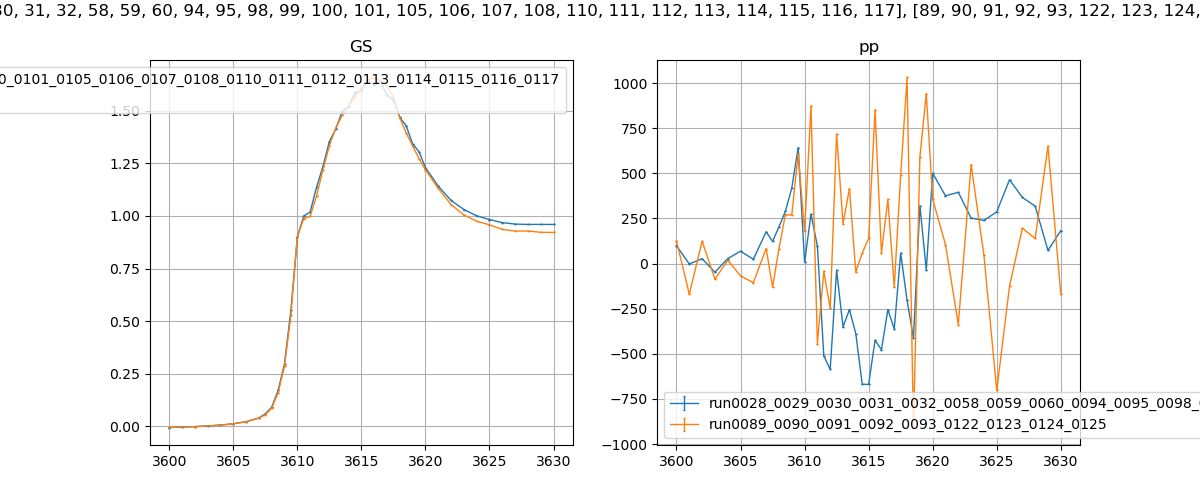

In [104]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'lower left')
ax3.set_title('pp')
ax3.grid()
plt.show()

# Overlay data "manually"

In [51]:
pgroup = 'p22588'
runlist2load = [[100], [101], [102], [103]]

which_plot = 'plot1' #plot_both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
#selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0100/data.npz
Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0101/data.npz
Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0102/data.npz
Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0103/data.npz


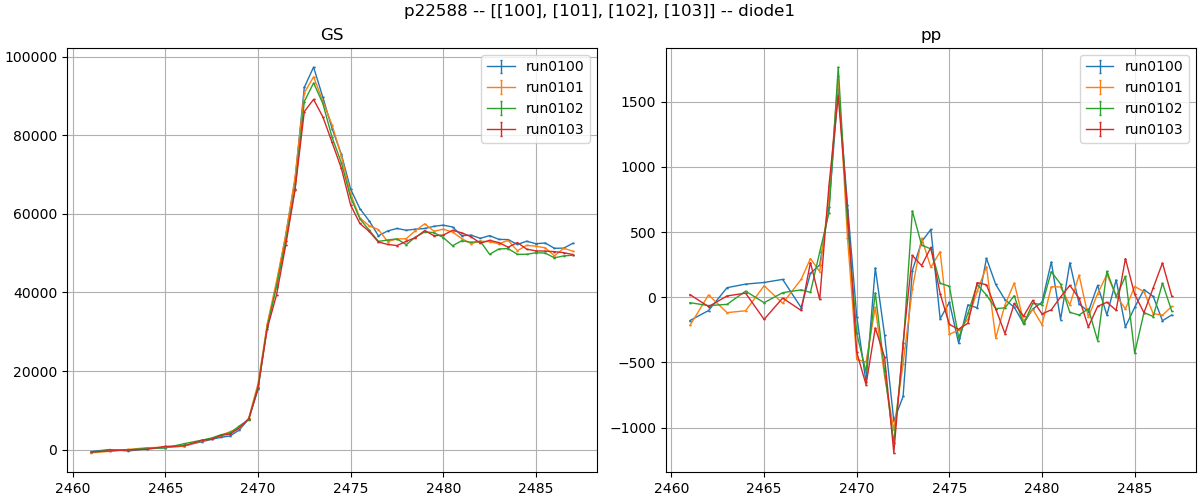

In [52]:
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
ax3.set_title('pp')
ax3.grid()
plt.show()
